In [1]:
import sys
import os
import time

import mlflow
import numpy as np
import pandas as pd
import catboost as cb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score as auc

sys.path.append(os.path.abspath("../src"))
os.environ["MLFLOW_TRACKING_URI"] = "http://127.0.0.1:5000"

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
from Preprocessing import Preprocessor
from postgres_connection import connection, all_tables
from utils import create_submission

In [4]:
start_time = time.time()

# Data loading

In [5]:
tables = all_tables()
display(tables)

,table_name
0,application_train
1,previous_application
2,credit_card_balance
3,bureau_balance
4,application_test
5,bureau
6,homecredit_columns_description
7,installments_payments
8,sample_submission
9,pos_cash_balance


In [6]:
df_description = connection("dwh.homecredit_columns_description;")
df_description.head(10)

,column1,table,row,description,special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,
1,2,application_{train|test}.csv,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,


In [7]:
df_train = connection("dwh.application_train;")
df_train.head()

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,243178,0,Cash loans,F,N,Y,1,72000.0,432288.0,12015.0,342000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.031329,-10247,-950,-4441.0,-1672,NaN,1,1,0,1,0,0,Core staff,3.0,2,2,MONDAY,11,0,0,0,1,1,1,Bank,NaN,0.165183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,2.0,0.0,2.0,0.0,-1001.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,243179,1,Cash loans,F,N,N,0,405000.0,2250000.0,59485.5,2250000.0,Unaccompanied,Commercial associate,Higher education,Single / not married,House / apartment,0.031329,-16610,-6462,-2569.0,-148,NaN,1,1,0,1,1,0,Accountants,1.0,2,2,SATURDAY,15,0,0,0,0,0,0,Business Entity Type 3,NaN,0.619734,0.538863,0.3330,0.0735,0.9881,0.8368,0.0369,0.36,0.3103,0.3333,0.375,0.3362,0.2639,0.3126,0.0347,0.0713,0.3393,0.0763,0.9881,0.8432,0.0373,0.3625,0.3103,0.3333,0.375,0.3439,0.2883,0.3257,0.035,0.0755,0.3362,0.0735,0.9881,0.839,0.0372,0.36,0.3103,0.3333,0.375,0.342,0.2685,0.3182,0.0349,0.0728,reg oper account,block of flats,0.2816,Panel,No,1.0,0.0,1.0,0.0,-4.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,243180,0,Revolving loans,F,N,Y,0,157500.0,337500.0,16875.0,337500.0,Family,Pensioner,Secondary / secondary special,Married,House / apartment,0.022625,-20683,365243,-3190.0,-4037,NaN,1,0,0,1,0,0,,2.0,2,2,TUESDAY,11,0,0,0,0,0,0,XNA,0.709645,0.544906,0.621226,0.0165,NaN,0.9776,NaN,NaN,0.00,0.0690,0.0417,NaN,NaN,NaN,0.0130,NaN,0.0129,0.0168,NaN,0.9777,NaN,NaN,0.0000,0.0690,0.0417,NaN,NaN,NaN,0.0135,NaN,0.0137,0.0167,NaN,0.9776,NaN,NaN,0.00,0.0690,0.0417,NaN,NaN,NaN,0.0132,NaN,0.0132,,block of flats,0.0169,Panel,No,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,

In [8]:
description = df_train.describe().T
description['nans'] = df_train.shape[0] - description["count"]
description = description.T
description.T.describe()

,count,mean,std,min,25%,50%,75%,max,nans
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,1.060000e+02,106.000000
mean,228378.037736,15569.773160,12055.477374,1259.136938,7461.422425,13097.637775,19582.492814,1.190315e+06,79132.962264
std,88679.981781,83608.079267,59368.148164,12264.697714,40597.693041,72241.697770,109202.512379,1.136914e+07,88679.981781
min,92646.000000,-16036.995067,0.001803,-25229.000000,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03,0.000000
25%,143620.000000,0.016575,0.074842,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
50%,306490.000000,0.101365,0.112163,0.000000,0.000000,0.011225,0.099200,1.000000e+00,1021.000000
75%,307511.000000,0.480860,0.384164,0.000000,0.083300,0.197900,0.667697,1.000000e+00,163891.000000
max,307511.000000,599025.999706,402490.776996,100002.000000,270000.000000,513531.000000,808650.000000,1.170000e+08,214865.000000


In [9]:
aux = ['sk_id_curr']  # Вспомогательный список с колонной, которую нужно исключить
target = ['target']  # Целевая переменная
categ = [col for col in df_train.columns if col not in (aux + target) and df_train[col].nunique() <= 7] + \
        [col for col in df_train.columns if col not in (aux + target) and df_train[col].dtypes == np.dtype('O')]
categ = list(set(categ))

nums = [col for col in df_train.columns if col not in (categ + target + aux)]

# Вывод количества категориальных и числовых переменных
print(f"Список категориальных переменных: {len(categ)}")
print(f"Список числовых переменных: {len(nums)}")

Список категориальных переменных: 51
Список числовых переменных: 69


In [10]:
col_nunique = {col: df_train[col].nunique() for col in df_train.columns if col not in aux + target}
col_nunique


{'name_contract_type': 2,
 'code_gender': 3,
 'flag_own_car': 2,
 'flag_own_realty': 2,
 'cnt_children': 15,
 'amt_income_total': 2548,
 'amt_credit': 5603,
 'amt_annuity': 13672,
 'amt_goods_price': 1002,
 'name_type_suite': 8,
 'name_income_type': 8,
 'name_education_type': 5,
 'name_family_status': 6,
 'name_housing_type': 6,
 'region_population_relative': 81,
 'days_birth': 17460,
 'days_employed': 12574,
 'days_registration': 15688,
 'days_id_publish': 6168,
 'own_car_age': 62,
 'flag_mobil': 2,
 'flag_emp_phone': 2,
 'flag_work_phone': 2,
 'flag_cont_mobile': 2,
 'flag_phone': 2,
 'flag_email': 2,
 'occupation_type': 19,
 'cnt_fam_members': 17,
 'region_rating_client': 3,
 'region_rating_client_w_city': 3,
 'weekday_appr_process_start': 7,
 'hour_appr_process_start': 24,
 'reg_region_not_live_region': 2,
 'reg_region_not_work_region': 2,
 'live_region_not_work_region': 2,
 'reg_city_not_live_city': 2,
 'reg_city_not_work_city': 2,
 'live_city_not_work_city': 2,
 'organization_typ

In [11]:
df_train['code_gender'].value_counts()

code_gender
F      202448
M      105059
XNA         4
Name: count, dtype: int64

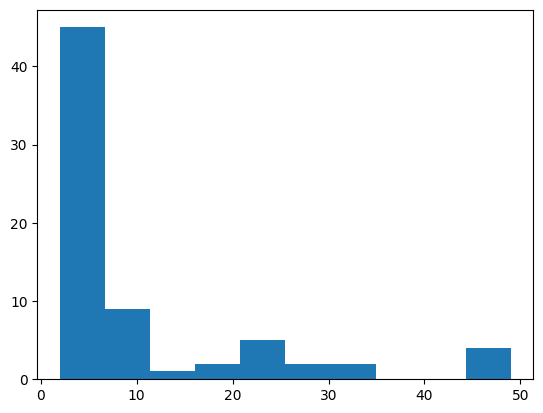

In [12]:
plt.hist(list(filter(lambda x: x <= 50, col_nunique.values())))
plt.show()


# Create Dataset


In [13]:
prep = Preprocessor()
prep_df_train = prep.fit_predict(df_train)
prep_df_train

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,243178,0,Cash loans,F,N,Y,1,72000.0,432288.0,12015.0,342000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.031329,-10247,-950,-4441.0,-1672,NaN,1,1,0,1,0,0,Core staff,3.0,2,2,MONDAY,11,0,0,0,1,1,1,Bank,NaN,0.165183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,2.0,0.0,2.0,0.0,-1001.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,nan,NaN,NaN,NaN,NaN,NaN
1,243179,1,Cash loans,F,N,N,0,405000.0,2250000.0,59485.5,2250000.0,Unaccompanied,Commercial associate,Higher education,Single / not married,House / apartment,0.031329,-16610,-6462,-2569.0,-148,NaN,1,1,0,1,1,0,Accountants,1.0,2,2,SATURDAY,15,0,0,0,0,0,0,Business Entity Type 3,NaN,0.619734,0.538863,0.3330,0.0735,0.9881,0.8368,0.0369,0.36,0.3103,0.3333,0.3750,0.3362,0.2639,0.3126,0.0347,0.0713,0.3393,0.0763,0.9881,0.8432,0.0373,0.3625,0.3103,0.3333,0.3750,0.3439,0.2883,0.3257,0.0350,0.0755,0.3362,0.0735,0.9881,0.8390,0.0372,0.36,0.3103,0.3333,0.3750,0.3420,0.2685,0.3182,0.0349,0.0728,reg oper account,block of flats,0.2816,Panel,No,1.0,0.0,1.0,0.0,-4.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,243180,0,Revolving loans,F,N,Y,0,157500.0,337500.0,16875.0,337500.0,Family,Pensioner,Secondary / secondary special,Married,House / apartment,0.022625,-20683,365243,-3190.0,-4037,NaN,1,0,0,1,0,0,,2.0,2,2,TUESDAY,11,0,0,0,0,0,0,XNA,0.709645,0.544906,0.621226,0.0165,NaN,0.9776,NaN,NaN,0.00,0.0690,0.0417,NaN,NaN,NaN,0.0130,NaN,0.0129,0.0168,NaN,0.9777,NaN,NaN,0.0000,0.0690,0.0417,NaN,NaN,NaN,0.0135,NaN,0.0137,0.0167,NaN,0.9776,NaN,NaN,0.00,0.0690,0.0417,NaN,NaN,NaN,0.0132,NaN,0.0132,,block of flats,0.0169,Panel,No,0.0,0.0,0.0,0.0,0.0,0,0,0,

In [14]:
X_train, X_test = train_test_split(prep_df_train, test_size=0.25, stratify=df_train['target'])
X_train


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
195279,113064,0,Cash loans,M,N,Y,0,405000.0,1327500.0,126045.0,1327500.0,Unaccompanied,Commercial associate,Incomplete higher,Civil marriage,House / apartment,0.035792,-12963,-4240,-6993.0,-1328,NaN,1,1,1,1,1,0,,2.0,2,2,TUESDAY,13,0,0,0,0,0,0,Business Entity Type 3,NaN,0.562601,0.570917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,0.0,0.0,0.0,0.0,-1898.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
78947,334691,0,Cash loans,M,Y,Y,2,135000.0,284400.0,13963.5,225000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.025164,-13162,-389,-327.0,-4047,12.0,1,1,0,1,0,0,Laborers,4.0,2,2,SATURDAY,11,0,0,0,0,0,0,Industry: type 1,0.205603,0.641807,0.639708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,7.0,0.0,7.0,0.0,-105.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
297659,231748,0,Cash loans,F,N,Y,0,270000.0,630000.0,32296.5,630000.0,Unaccompanied,Working,Incomplete higher,Separated,House / apartment,0.007114,-13471,-2926,-5774.0,-1513,NaN,1,1,0,1,1,0,Managers,1.0,2,2,THURSDAY,15,0,0,0,0,0,0,Business Entity Type 3,0.516745,0.619420,0.249885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,0.0,0.0,0.0,0.0,-2387.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
167799,437414,0,Cash loans,F,N,Y,0,261000.0,500211.0,30730.5,463500.0,Unaccompanied,State servant,Higher education,Single / not married,With parents,0.0020

In [15]:
train_pool = cb.Pool(
    X_train[categ + nums],  # Тренировочные данные (категориальные + числовые признаки)
    label=X_train[target[0]],  # Целевая переменная для обучения
    cat_features=categ  # Список категориальных признаков
)

test_pool = cb.Pool(
    X_test[categ + nums],  # Тестовые данные (категориальные + числовые признаки)
    label=X_test[target[0]],  # Целевая переменная для тестирования
    cat_features=categ  # Список категориальных признаков
)


# Learn Model

In [18]:

clf = cb.CatBoostClassifier(
    iterations=1000,  # Количество итераций
    verbose=20,       # Вывод каждые 20 итераций
    eval_metric='AUC' # Метрика оценки качества
)
mlflow.set_experiment("rishon")

mlflow.autolog()
with mlflow.start_run():
    # Обучение модели на тренировочных данных
    clf.fit(train_pool, plot=True, verbose_eval=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.105172
0:	total: 253ms	remaining: 4m 13s
1:	total: 426ms	remaining: 3m 32s
2:	total: 590ms	remaining: 3m 16s
3:	total: 759ms	remaining: 3m 9s
4:	total: 944ms	remaining: 3m 7s
5:	total: 1.11s	remaining: 3m 4s
6:	total: 1.26s	remaining: 2m 58s
7:	total: 1.42s	remaining: 2m 56s
8:	total: 1.6s	remaining: 2m 56s
9:	total: 1.74s	remaining: 2m 51s
10:	total: 1.87s	remaining: 2m 47s
11:	total: 2.01s	remaining: 2m 45s
12:	total: 2.2s	remaining: 2m 46s
13:	total: 2.49s	remaining: 2m 55s
14:	total: 2.81s	remaining: 3m 4s
15:	total: 3.04s	remaining: 3m 6s
16:	total: 3.17s	remaining: 3m 3s
17:	total: 3.34s	remaining: 3m 2s
18:	total: 3.51s	remaining: 3m 1s


KeyboardInterrupt: 

In [ ]:
#mlflow.log_metric("auc_train", auc(X_train[prep.target[0]], clf.predict_proba(train_pool)[:, 1]))
#mlflow.log_metric("auc_test", auc(X_test[prep.target[0]], clf.predict_proba(test_pool)[:, 1]))
#mlflow.catboost.log_model(clf, "model")


In [ ]:
mlflow.end_run()

In [ ]:
X_train.columns = map(str.lower, X_train.columns)  # Посмотрите точное написание всех колонок
X_test.columns = map(str.lower, X_test.columns) 

In [ ]:
# Оценка качества на тренировочных данных
print(f'Train: {auc(X_train[prep.target[0]], clf.predict_proba(train_pool)[:, 1])}')

# Оценка качества на тестовых данных
print(f'Test: {auc(X_test[prep.target[0]], clf.predict_proba(test_pool)[:, 1])}')

In [ ]:
#mlflow.log_metric("train_auc", clf.score(X_train, X_train['target']))

# Submit

In [ ]:
df_test = connection('dwh.application_test;')
prep_test = prep.fit_predict(df_test)
prep_test.head()

In [ ]:
prep_pool = cb.Pool(
    prep_test[categ + nums],
    cat_features=categ
)
prediction = clf.predict_proba(prep_pool)[:, 1]

In [ ]:
create_submission(connection('dwh.sample_submission;'), pd.Series(prediction))

In [ ]:
end_time = time.time()
print(f"Время работы: {end_time - start_time} c")
